### Problem 1

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import chisquare


def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]


def serial_test(sequence, k, bins=10):
    sequence = np.array(sequence)
    n = len(sequence)

    m = n // k
    trimmed = sequence[:m * k]

    points = trimmed.reshape((m, k))

    hist, edges = np.histogramdd(points, bins=[bins]*k, range=[[0,1]]*k)

    observed = hist.flatten()
    
    expected = np.full_like(observed, fill_value=m / (bins**k), dtype=float)

    chi2, p_value = chisquare(observed, expected)

    return chisquare(observed, expected)

serial_test(samples, 2, bins=15)

Power_divergenceResult(statistic=np.float64(255.09999999999997), pvalue=np.float64(0.07528556709734432))

### Problem 2

In [ ]:
import numpy as np
import itertools

def get_permutation_index(block):
    ranks = np.argsort(block)
    return tuple(ranks)


def permutation_test(sequence, d=3):
    sequence = np.array(sequence)
    n = len(sequence) // d

    blocks = sequence[:n*d].reshape(n, d)

    perms = list(itertools.permutations(range(d)))
    perm_index = {p: i for i, p in enumerate(perms)}

    counts = np.zeros(len(perms))

    for block in blocks:
        p = get_permutation_index(block)
        counts[perm_index[p]] += 1

    expected = n / len(perms)

    chi2 = np.sum((counts - expected)**2 / expected)

    return chi2, counts

permutation_test(samples, 3)

(np.float64(4.8558558558558556), array([49., 62., 61., 60., 57., 44.]))

### Problem 3

In [4]:
n = 1000

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1


def generate_samples(rng_func, n):
    return np.array([rng_func() for _ in range(n)])
    

sample_bad = generate_samples(rng_bad, n)

rng.current = 1
sample_good = generate_samples(rng, n)

chi2_bad, p_bad = serial_test(sample_bad, k=2)
chi2_good, p_good = serial_test(sample_good, k=2)

print("BAD RNG  -> chi2:", chi2_bad, "p-value:", p_bad)
print("GOOD RNG -> chi2:", chi2_good, "p-value:", p_good)

BAD RNG  -> chi2: 127.60000000000001 p-value: 0.02802262075660813
GOOD RNG -> chi2: 114.39999999999999 p-value: 0.1380441495447643


### Problem 4

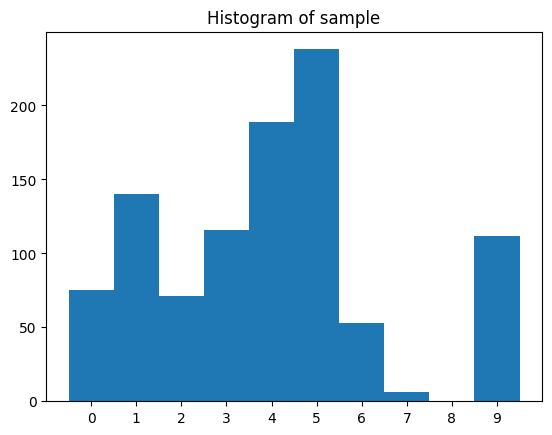

In [ ]:
import matplotlib.pyplot as plt

digits = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

weights = weights / weights.sum()

cdf = np.cumsum(weights)

def sample_one():
    u = np.random.rand()
    return np.searchsorted(cdf, u)

sample = np.array([sample_one() for _ in range(1000)])

plt.hist(sample, bins=np.arange(11)-0.5)
plt.xticks(range(10))
plt.title("Histogram of sample")
plt.show()

### Problem 5

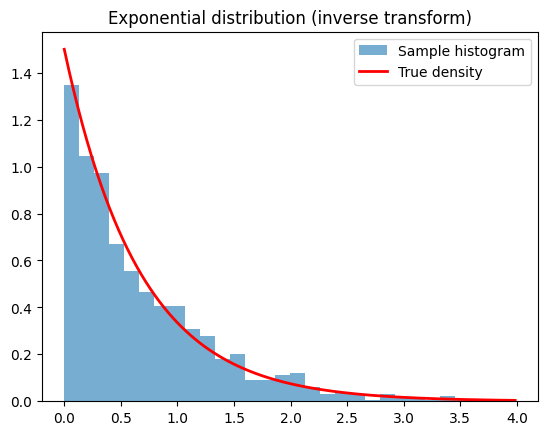

In [ ]:
lam = 1.5
n = 1000

U = np.random.rand(n)

X = -np.log(U) / lam

x_vals = np.linspace(0, max(X), 200)
pdf = lam * np.exp(-lam * x_vals)

plt.hist(X, bins=30, density=True, alpha=0.6, label="Sample histogram")
plt.plot(x_vals, pdf, 'r', lw=2, label="True density")

plt.title("Exponential distribution (inverse transform)")
plt.legend()
plt.show()

### Problem 6

C:\Users\Саша\AppData\Local\Temp\ipykernel_50052\2265806984.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(unnormalized, x)


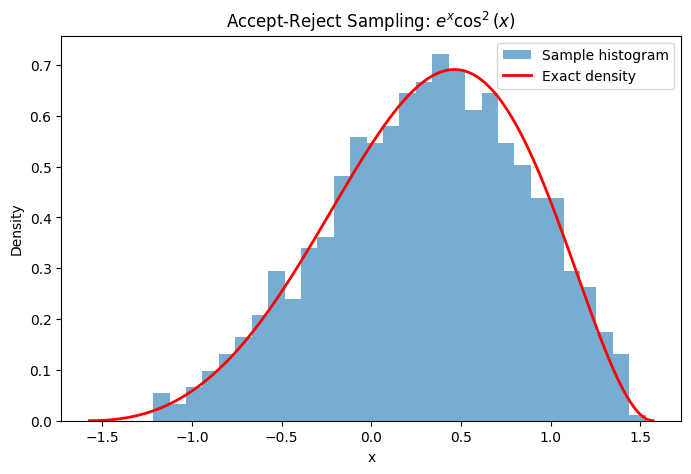

In [ ]:
def density(x):
    return np.exp(x) * np.cos(x)**2

M = np.exp(np.pi/2)

def sample_accept_reject(n):
    samples = []

    while len(samples) < n:
        x = np.random.uniform(-np.pi/2, np.pi/2)

        y = np.random.uniform(0, M)

        if y <= density(x):
            samples.append(x)

    return np.array(samples)

samples = sample_accept_reject(1000)

x = np.linspace(-np.pi/2, np.pi/2, 500)

unnormalized = density(x)

Z = np.trapz(unnormalized, x)

normalized_density = unnormalized / Z

plt.figure(figsize=(8,5))

plt.hist(samples, bins=30, density=True, alpha=0.6, label='Sample histogram')

plt.plot(x, normalized_density, 'r', lw=2, label='Exact density')

plt.xlabel('x')
plt.ylabel('Density')
plt.title(r'Accept-Reject Sampling: $e^x \cos^2(x)$')

plt.legend()
plt.show()

### Problem 7

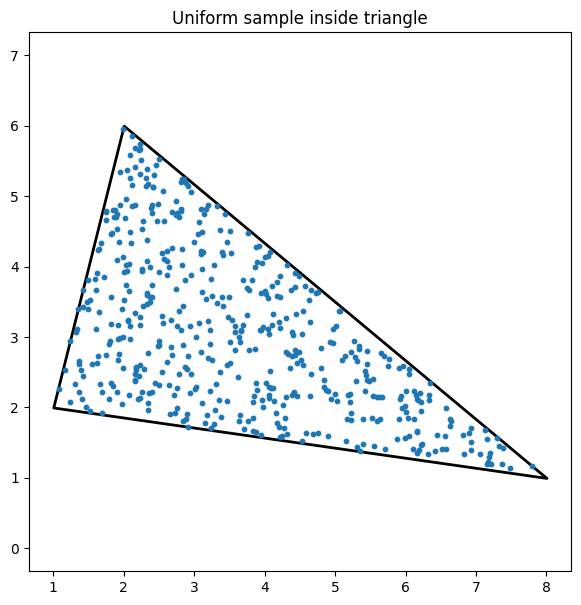

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n = 500

u = np.random.rand(n)
v = np.random.rand(n)

mask = (u + v > 1)
u[mask] = 1 - u[mask]
v[mask] = 1 - v[mask]

points = A + np.outer(u, B - A) + np.outer(v, C - A)

fig = plt.figure(figsize=(7,7))

polygon = Polygon(
    xy=np.array([A, B, C]),
    closed=True,
    fill=False,
    edgecolor='black',
    linewidth=2
)

plt.gca().add_collection(PatchCollection([polygon], match_original=True))

plt.scatter(points[:,0], points[:,1], s=10)

plt.axis('equal')
plt.title("Uniform sample inside triangle")

plt.show()

### Problem 8

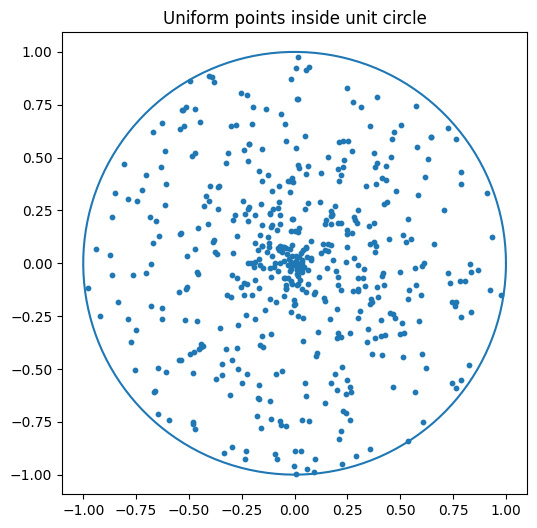

In [ ]:
n = 500

u1 = np.random.rand(n)
u2 = np.random.rand(n)

r = np.sqrt(u1)

phi = 2 * np.pi * u2

x = r * np.cos(phi)
y = r * np.sin(phi)


plt.figure(figsize=(6,6))

plt.scatter(x, y, s=10)

theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta))

plt.axis('equal')
plt.title("Uniform points inside unit circle")

plt.show()

### Problem 9

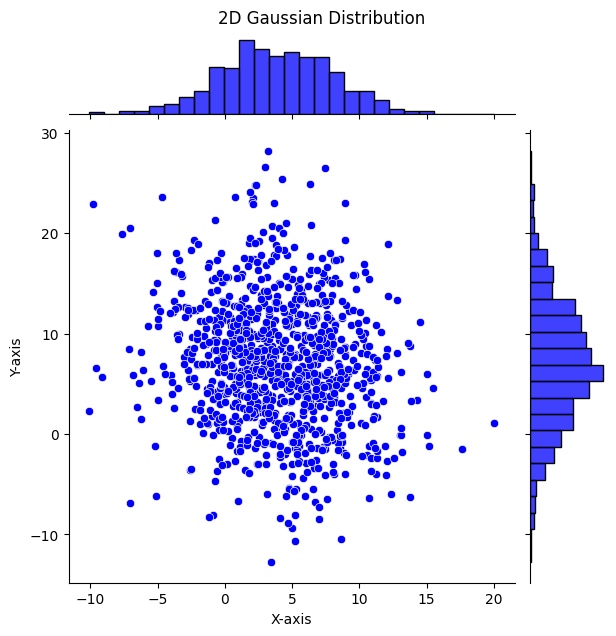

In [ ]:
import seaborn as sns

def box_muller_polar(n):
    samples = []

    while len(samples) < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)

        s = u*u + v*v

        if s == 0 or s >= 1:
            continue

        factor = np.sqrt(-2 * np.log(s) / s)

        z1 = u * factor
        z2 = v * factor

        samples.extend([z1, z2])

    return np.array(samples[:n])

mu = np.array([4, 7])

Sigma = np.array([
    [20, -4],
    [-4, 40]
])

A = np.linalg.cholesky(Sigma)

n = 1000

z = box_muller_polar(2 * n).reshape(n, 2)

x = mu + z @ A.T

joint_plot = sns.jointplot(x=x[:,0], y=x[:,1], color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()
